<a href="https://colab.research.google.com/github/Rogerio-mack/IA_Classica2Agentes/blob/main/AI_ConstraintSatisfation_Schedulling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CSP (Constraint Satisfaction Problems)**

Modelar o tempo e os recursos como variáveis com restrições. Ex: Início_Tarefa_B > Fim_Tarefa_A.

In [ ]:
!pip install ortools

In [ ]:
from graphviz import Digraph

# =========================
# Variáveis e domínios
# =========================

variables = ["A", "B", "C"]

domains = {
    "A": [1,2,3],
    "B": [1,2,3],
    "C": [1,2,3]
}

# =========================
# Restrições
# =========================

def constraints(assignment):

    # A != B
    if "A" in assignment and "B" in assignment:
        if assignment["A"] == assignment["B"]:
            return False

    # B != C
    if "B" in assignment and "C" in assignment:
        if assignment["B"] == assignment["C"]:
            return False

    # A < C
    if "A" in assignment and "C" in assignment:
        if assignment["A"] >= assignment["C"]:
            return False

    return True

# =========================
# Grafo da busca
# =========================

tree = Digraph()

node_counter = 0

# =========================
# Backtracking
# =========================

def backtrack(assignment, parent=None):

    global node_counter

    node_id = str(node_counter)
    node_counter += 1

    label = str(assignment)

    tree.node(node_id, label)

    if parent is not None:
        tree.edge(parent, node_id)

    # Solução completa
    if len(assignment) == len(variables):
        print("Solução encontrada:", assignment)
        return assignment

    # Próxima variável
    unassigned = [
        v for v in variables
        if v not in assignment
    ]

    var = unassigned[0]

    # Testar valores
    for value in domains[var]:

        print(f"Tentando {var}={value}")

        new_assignment = assignment.copy()
        new_assignment[var] = value

        # Verificar restrições
        if constraints(new_assignment):

            result = backtrack(
                new_assignment,
                node_id
            )

            if result is not None:
                return result

        else:
            print(
                f"Falha: {new_assignment}"
            )

            fail_id = str(node_counter)
            node_counter += 1

            tree.node(
                fail_id,
                str(new_assignment),
                color="red"
            )

            tree.edge(node_id, fail_id)

    print("Backtracking...")

    return None

# =========================
# Executar
# =========================

solution = backtrack({})

print("\nSolução final:")
print(solution)

# =========================
# Salvar árvore
# =========================

tree.render(
    "csp_search_tree",
    format="png",
    cleanup=True
)

print("\nÁrvore salva.")

Tentando A=1
Tentando B=1
Falha: {'A': 1, 'B': 1}
Tentando B=2
Tentando C=1
Falha: {'A': 1, 'B': 2, 'C': 1}
Tentando C=2
Falha: {'A': 1, 'B': 2, 'C': 2}
Tentando C=3
Solução encontrada: {'A': 1, 'B': 2, 'C': 3}

Solução final:
{'A': 1, 'B': 2, 'C': 3}

Árvore salva.


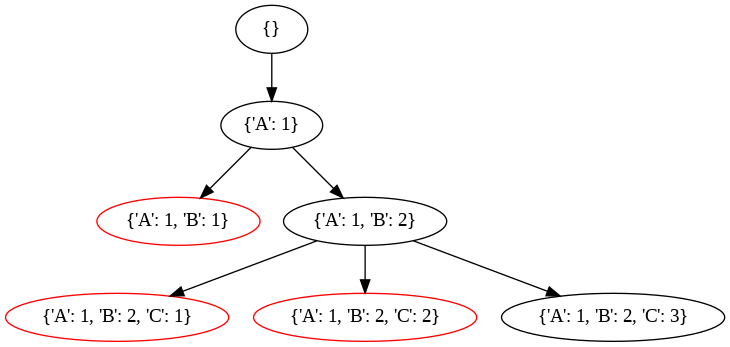

In [ ]:
from IPython.display import Image
Image('/content/csp_search_tree.png')

In [ ]:
from ortools.sat.python import cp_model

# =========================
# Dados do problema
# =========================

# Cada tarefa:
# (nome, duração, laboratório)

tasks = [
    ("T1", 3, "Lab1"),
    ("T2", 2, "Lab1"),
    ("T3", 4, "Lab2"),
    ("T4", 3, "Lab2"),
    ("T5", 2, "Lab3"),
    ("T6", 5, "Lab3"),
    ("T7", 4, "Lab1"),
    ("T8", 3, "Lab2"),
]

# Dependências:
# tarefa A deve terminar antes de B começar

dependencies = [
    ("T1", "T3"),
    ("T2", "T4"),
    ("T3", "T6"),
    ("T5", "T8"),
]

# =========================
# Modelo
# =========================

model = cp_model.CpModel()

# Horizonte máximo
horizon = sum(task[1] for task in tasks)

# Variáveis
task_vars = {}

for name, duration, lab in tasks:

    start = model.NewIntVar(0, horizon, f"start_{name}")
    end = model.NewIntVar(0, horizon, f"end_{name}")

    interval = model.NewIntervalVar(
        start,
        duration,
        end,
        f"interval_{name}"
    )

    task_vars[name] = {
        "start": start,
        "end": end,
        "interval": interval,
        "duration": duration,
        "lab": lab
    }

# =========================
# Restrição:
# Não sobrepor tarefas
# no mesmo laboratório
# =========================

labs = {}

for name, _, lab in tasks:
    labs.setdefault(lab, []).append(
        task_vars[name]["interval"]
    )

for lab, intervals in labs.items():
    model.AddNoOverlap(intervals)

# =========================
# Dependências
# =========================

for before, after in dependencies:
    model.Add(
        task_vars[before]["end"] <=
        task_vars[after]["start"]
    )

# =========================
# Objetivo:
# minimizar makespan
# =========================

makespan = model.NewIntVar(0, horizon, "makespan")

model.AddMaxEquality(
    makespan,
    [task_vars[t[0]]["end"] for t in tasks]
)

model.Minimize(makespan)

# =========================
# Resolver
# =========================

solver = cp_model.CpSolver()

status = solver.Solve(model)

# =========================
# Resultados
# =========================

if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:

    print(f"Makespan ótimo: {solver.Value(makespan)}\n")

    for name, duration, lab in tasks:

        start = solver.Value(task_vars[name]["start"])
        end = solver.Value(task_vars[name]["end"])

        print(
            f"{name} | "
            f"{lab} | "
            f"Início: {start} | "
            f"Fim: {end}"
        )

else:
    print("Nenhuma solução encontrada.")

Makespan ótimo: 13

T1 | Lab1 | Início: 0 | Fim: 3
T2 | Lab1 | Início: 3 | Fim: 5
T3 | Lab2 | Início: 3 | Fim: 7
T4 | Lab2 | Início: 7 | Fim: 10
T5 | Lab3 | Início: 0 | Fim: 2
T6 | Lab3 | Início: 7 | Fim: 12
T7 | Lab1 | Início: 5 | Fim: 9
T8 | Lab2 | Início: 10 | Fim: 13


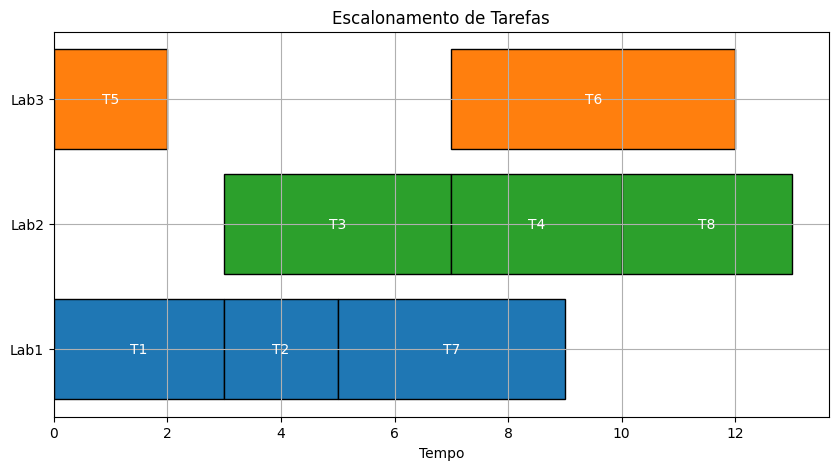

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,5))

colors = {
    "Lab1": "tab:blue",
    "Lab2": "tab:green",
    "Lab3": "tab:orange"
}

y_pos = {
    "Lab1": 1,
    "Lab2": 2,
    "Lab3": 3
}

for name, duration, lab in tasks:

    start = solver.Value(task_vars[name]["start"])

    ax.barh(
        y_pos[lab],
        duration,
        left=start,
        color=colors[lab],
        edgecolor='black'
    )

    ax.text(
        start + duration/2,
        y_pos[lab],
        name,
        va='center',
        ha='center',
        color='white'
    )

ax.set_yticks([1,2,3])
ax.set_yticklabels(["Lab1", "Lab2", "Lab3"])

ax.set_xlabel("Tempo")
ax.set_title("Escalonamento de Tarefas")

plt.grid(True)
plt.show()